In [1]:
import os

DATA_DIR = "../data/aclImdb"

TRAIN_DIR = os.path.join(
    DATA_DIR,
    "train"
)

TEST_DIR = os.path.join(
    DATA_DIR,
    "test"
)

print("Training folders:")
print(os.listdir(TRAIN_DIR))

print("\nTesting folders:")
print(os.listdir(TEST_DIR))

Training folders:
['labeledBow.feat', 'neg', 'pos', 'unsup', 'unsupBow.feat', 'urls_neg.txt', 'urls_pos.txt', 'urls_unsup.txt']

Testing folders:
['labeledBow.feat', 'neg', 'pos', 'urls_neg.txt', 'urls_pos.txt']


In [2]:
import os


train_pos = os.path.join(
    TRAIN_DIR,
    "pos"
)

train_neg = os.path.join(
    TRAIN_DIR,
    "neg"
)

test_pos = os.path.join(
    TEST_DIR,
    "pos"
)

test_neg = os.path.join(
    TEST_DIR,
    "neg"
)


print("Training:")
print("Positive:", len(os.listdir(train_pos)))
print("Negative:", len(os.listdir(train_neg)))

print("\nTesting:")
print("Positive:", len(os.listdir(test_pos)))
print("Negative:", len(os.listdir(test_neg)))

Training:
Positive: 12500
Negative: 12500

Testing:
Positive: 12500
Negative: 12500


In [3]:
import os


def read_review(folder_path, filename):
    file_path = os.path.join(
        folder_path,
        filename
    )

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as f:
        return f.read()


# Get one positive and one negative review
positive_files = os.listdir(train_pos)
negative_files = os.listdir(train_neg)

positive_review = read_review(
    train_pos,
    positive_files[0]
)

negative_review = read_review(
    train_neg,
    negative_files[0]
)


print("=" * 70)
print("POSITIVE REVIEW")
print("=" * 70)

print(positive_review)


print("\n" + "=" * 70)
print("NEGATIVE REVIEW")
print("=" * 70)

print(negative_review)

POSITIVE REVIEW
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!

NEGATIVE REVIEW
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is

In [4]:
import os
import pandas as pd


def load_reviews(folder_path, label):
    reviews = []

    for filename in os.listdir(folder_path):

        if not filename.endswith(".txt"):
            continue

        file_path = os.path.join(
            folder_path,
            filename
        )

        with open(
            file_path,
            "r",
            encoding="utf-8"
        ) as f:

            review = f.read()

        reviews.append({
            "review": review,
            "sentiment": label
        })

    return reviews


# Load training data
positive_train = load_reviews(
    train_pos,
    1
)

negative_train = load_reviews(
    train_neg,
    0
)


# Load testing data
positive_test = load_reviews(
    test_pos,
    1
)

negative_test = load_reviews(
    test_neg,
    0
)


# Combine everything
data = (
    positive_train
    + negative_train
    + positive_test
    + negative_test
)

df = pd.DataFrame(data)


# Shuffle the dataset
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


print("Dataset shape:", df.shape)

print("\nSentiment distribution:")
print(
    df["sentiment"].value_counts()
)

print("\nFirst 5 rows:")
print(
    df.head()
)

Dataset shape: (50000, 2)

Sentiment distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64

First 5 rows:
                                              review  sentiment
0  When I first saw the ad for this, I was like '...          1
1  "A Girl's Folly" is a sort of half-comedy, hal...          1
2  I started watching the show from the first sea...          1
3  This is a more interesting than usual porn mov...          1
4  I suppose for 1961 this film was supposed to b...          0


In [5]:
# ============================================================
# DATA QUALITY CHECK
# ============================================================

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate reviews:")
print(df["review"].duplicated().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate reviews:
418

Duplicate rows:
418


In [6]:
def load_reviews(folder_path,label,split):
    reviews = []

    for filename in os.listdir(folder_path):
        if not filename.endswith(".txt"):
            continue

        file_path = os.path.join(folder_path, filename)
        with open(file_path, "r", encoding="utf-8") as f:
            review = f.read()
        reviews.append({
            "review": review,
            "sentiment": label,
            "split": split
        })
    return reviews

positive_train = load_reviews(train_pos,1,"train")
negative_train = load_reviews(train_neg,0,"train")
positive_test = load_reviews(test_pos,1,"test")
negative_test = load_reviews(test_neg,0,"test")

data = (positive_train + negative_train + positive_test + negative_test)

df = pd.DataFrame(data)
df = df.sample(frac = 1, random_state = 42).reset_index(drop = True)
print(df.shape)
print(df["split"].value_counts())

(50000, 3)
split
test     25000
train    25000
Name: count, dtype: int64


In [7]:
train_reviews = set(
    df[df["split"] == "train"]["review"]
)
test_reviews = set(
    df[df["split"] =="test"]["review"]
)
cross_split_duplicates = train_reviews.intersection(test_reviews)
print("train reviews:", len(train_reviews))
print("Test reviews:", len(test_reviews))
print("Train-Test duplicate reviews:", len(cross_split_duplicates))

train reviews: 24904
Test reviews: 24801
Train-Test duplicate reviews: 123


In [8]:
import numpy as np

df["review_length"]  = df["review"].apply(lambda x : len(x.split()))

print("Minimum length:", df["review_length"].min())
print("Maximum length:", df["review_length"].max())
print("Average length:", df["review_length"].mean())
print("Median length:", df["review_length"].median())

print("\n Percentiles:")
print("90th percentile:", np.percentile(df["review_length"], 90))
print("95th percentile:", np.percentile(df["review_length"], 95))
print("99th percentile:", np.percentile(df["review_length"], 99))

Minimum length: 4
Maximum length: 2470
Average length: 231.15694
Median length: 173.0

 Percentiles:
90th percentile: 451.0
95th percentile: 590.0
99th percentile: 908.0


In [9]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>"," ", text)
    text = re.sub(r"[^a-z'\s]"," ", text)
    text = re.sub(r"\s+"," ",text).strip()
    return text

print("ORIGINAL:\n")
print(df.iloc[0]["review"][:1000])
print("\n\nCLEANED:\n")
print(clean_text(df.iloc[0]["review"])[:1000])

ORIGINAL:

When I first saw the ad for this, I was like 'Oh here we go. He's done High School Musical, but he can't coast along on that so now he's making appearances on other Disney shows'. Personally, I love The Suite Life and I'm a big fan of Ashely Tisdale. But for some reason, I'm not too keen on Zac Efron, although all my friends think he's the best thing since Jesse McCartney. But he really annoys me. Anyway, I watched the show (taking a break from English coursework) and was pleasantly surprised. The performances were good all round, especially from the regular characters on The Suite Life, and Zac Efron wasn't as bad as I had anticipated. All in all, a pretty good show.


CLEANED:

when i first saw the ad for this i was like 'oh here we go he's done high school musical but he can't coast along on that so now he's making appearances on other disney shows' personally i love the suite life and i'm a big fan of ashely tisdale but for some reason i'm not too keen on zac efron altho

In [10]:
df["cleaned_review"] = df["review"].apply(clean_text)
print(df[["review","cleaned_review","sentiment"]].head())
empty_reviews = (df["cleaned_review"].str.len() == 0).sum()
print("Empty reviews after cleaning:", empty_reviews)

                                              review  \
0  When I first saw the ad for this, I was like '...   
1  "A Girl's Folly" is a sort of half-comedy, hal...   
2  I started watching the show from the first sea...   
3  This is a more interesting than usual porn mov...   
4  I suppose for 1961 this film was supposed to b...   

                                      cleaned_review  sentiment  
0  when i first saw the ad for this i was like 'o...          1  
1  a girl's folly is a sort of half comedy half m...          1  
2  i started watching the show from the first sea...          1  
3  this is a more interesting than usual porn mov...          1  
4  i suppose for this film was supposed to be coo...          0  
Empty reviews after cleaning: 0


In [11]:
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

print("Before removing duplicates:")
print("Train:",len(train_df))
print("Test:", len(test_df))

train_review_set = set(train_df["review"])
test_review_set = set(test_df["review"])

cross_split_duplicates = train_review_set.intersection(test_review_set)
print("\n Cross_split_duplicates:", len(cross_split_duplicates))

test_df = test_df[
    ~test_df["review"].isin(cross_split_duplicates)
].copy()
print("\nAfter removing duplicates:")
print("Train:", len(train_df))
print("Test:", len(test_df))

Before removing duplicates:
Train: 25000
Test: 25000

 Cross_split_duplicates: 123

After removing duplicates:
Train: 25000
Test: 24877


In [12]:
print("\nTraining distribution:")
print(train_df["sentiment"].value_counts())

print("\nTest distribution:")
print(test_df["sentiment"].value_counts())


Training distribution:
sentiment
1    12500
0    12500
Name: count, dtype: int64

Test distribution:
sentiment
1    12472
0    12405
Name: count, dtype: int64


In [13]:
df.head()

,review,sentiment,split,review_length,cleaned_review
0,"When I first saw the ad for this, I was like '...",1,test,125,when i first saw the ad for this i was like 'o...
1,"""A Girl's Folly"" is a sort of half-comedy, hal...",1,train,167,a girl's folly is a sort of half comedy half m...
2,I started watching the show from the first sea...,1,train,150,i started watching the show from the first sea...
3,This is a more interesting than usual porn mov...,1,train,76,this is a more interesting than usual porn mov...
4,I suppose for 1961 this film was supposed to b...,0,test,176,i suppose for this film was supposed to be coo...


In [14]:
from sklearn.model_selection import train_test_split
X = train_df["cleaned_review"]
y = train_df["sentiment"]
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size = 0.10,random_state = 42,stratify = y)

X_test = test_df["cleaned_review"]
y_test = test_df["sentiment"]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\n Training distribution:")
print(y_train.value_counts())

print("\n Validation distribution:")
print(y_val.value_counts())

print("\n Test distribution:")
print(y_test.value_counts())

Training samples: 22500
Validation samples: 2500
Test samples: 24877

 Training distribution:
sentiment
0    11250
1    11250
Name: count, dtype: int64

 Validation distribution:
sentiment
0    1250
1    1250
Name: count, dtype: int64

 Test distribution:
sentiment
1    12472
0    12405
Name: count, dtype: int64


In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
VOCAB_SIZE = 20000
tokenizer = Tokenizer(
    num_words = VOCAB_SIZE,
    oov_token = "<OOV>"
)
tokenizer.fit_on_texts(X_train)
print("Total words learned:", len(tokenizer.word_index))
print("\n First 20 words:")
print(list(tokenizer.word_index.items())[:20])

Total words learned: 81858

 First 20 words:
[('<OOV>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9), ('i', 10), ('this', 11), ('that', 12), ('was', 13), ('as', 14), ('for', 15), ('with', 16), ('movie', 17), ('but', 18), ('film', 19), ('on', 20)]


In [17]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("First training review:")
print(X_train.iloc[0])

print("\nInteger sequences:")
print(X_train_seq[0])
print("\n Number of tokens:", len(X_train_seq[0]))

First training review:
this movie seemed like it was going to be better than it ended up being the cinematography is good the acting seemed solid the dialogue wasn't too stiff but then about twenty minutes in there's this long scene with a doctor who you know is actually a patient at the asylum pretending to be a doctor and it just goes south from there on top of that the demon is about the silliest looking hellspawn since the godzilla looking thing in curse of the demon there's also some odd demon worshippers who wear masks that look like the exploding teens from the beginning of logan's run in the end the cinematography couldn't save this movie despite some pretty solid performances by the actors the story just doesn't go anywhere i think hellbored would have been a better title for this

Integer sequences:
[11, 17, 465, 37, 9, 13, 166, 6, 26, 125, 71, 9, 1035, 53, 109, 2, 621, 7, 49, 2, 113, 465, 1144, 2, 410, 282, 96, 3322, 18, 92, 41, 1750, 228, 8, 222, 11, 194, 132, 16, 4, 1029, 

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 500
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen = MAX_LEN,
    padding = "post",
    truncating = "post"
)
X_val_pad = pad_sequences(
    X_val_seq,
    maxlen = MAX_LEN,
    padding = "post",
    truncating = "post"
)
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen = MAX_LEN,
    padding = "post",
    truncating = "post"
)
print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

Training shape: (22500, 500)
Validation shape: (2500, 500)
Test shape: (24877, 500)


In [21]:
print("Original sequence length:", len(X_train_seq[0]))
print("Padded sequence length:", len(X_train_pad[0]))

print("\nPadded sequence:")
print(X_train_pad[0])

Original sequence length: 140
Padded sequence length: 500

Padded sequence:
[   11    17   465    37     9    13   166     6    26   125    71     9
  1035    53   109     2   621     7    49     2   113   465  1144     2
   410   282    96  3322    18    92    41  1750   228     8   222    11
   194   132    16     4  1029    34    22   120     7   163     4  3034
    30     2  5294  4228     6    26     4  1029     3     9    40   268
  1268    36    47    20   342     5    12     2  2667     7    41     2
 15595   264     1   234     2  4195   264   150     8  3093     5     2
  2667   222    78    46  1023  2667     1    34  2594  4974    12   165
    37     2  6168  2477    36     2   449     5 12413   516     8     2
   127     2   621   423   601    11    17   462    46   181  1144   346
    31     2   153     2    62    40   149   137  1762    10   101     1
    59    25    74     4   125   420    15    11     0     0     0     0
     0     0     0     0     0     0     0     0

In [22]:
import tensorflow as tf
VOCAB_SIZE = 20000
EMBEDDING_DIM = 128

embedding_layer = tf.keras.layers.Embedding(
    input_dim = VOCAB_SIZE,
    output_dim = EMBEDDING_DIM,
    mask_zero = True
)
sample_input = X_train_pad[:2]
embedded_output = embedding_layer(sample_input)
print("Input shape:", sample_input.shape)
print("Embedding output shape:", embedded_output.shape)


Input shape: (2, 500)
Embedding output shape: (2, 500, 128)


In [24]:
import tensorflow as tf

VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = tf.keras.Sequential([
    tf.keras.Input(shape=(500,)),
    
    # Convert word IDs into dense vectors
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    # Learn sequence information
    tf.keras.layers.LSTM(LSTM_UNITS),

    # Binary sentiment prediction
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer="adam",
    loss = "binary_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully!")

Model compiled successfully!


In [28]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 225ms/step - accuracy: 0.7801 - loss: 0.4736 - val_accuracy: 0.8580 - val_loss: 0.3513
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 85s 240ms/step - accuracy: 0.8968 - loss: 0.2651 - val_accuracy: 0.8628 - val_loss: 0.3231
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 90s 255ms/step - accuracy: 0.9262 - loss: 0.1956 - val_accuracy: 0.8552 - val_loss: 0.3526
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 93s 265ms/step - accuracy: 0.9577 - loss: 0.1189 - val_accuracy: 0.8684 - val_loss: 0.3633


In [29]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    batch_size=64
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

389/389 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.8499 - loss: 0.3487
Test Loss: 0.348720520734787
Test Accuracy: 0.8499014973640442


In [30]:
import tensorflow as tf

model_dropout = tf.keras.Sequential([
    
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_dropout.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_dropout = model_dropout.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 220ms/step - accuracy: 0.7937 - loss: 0.4528 - val_accuracy: 0.8616 - val_loss: 0.3386
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.9059 - loss: 0.2490 - val_accuracy: 0.8756 - val_loss: 0.3107
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 135s 384ms/step - accuracy: 0.9449 - loss: 0.1589 - val_accuracy: 0.8768 - val_loss: 0.3572
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 396ms/step - accuracy: 0.7935 - loss: 0.4351 - val_accuracy: 0.8308 - val_loss: 0.4100


In [32]:
test_loss_dropout, test_accuracy_dropout = model_dropout.evaluate(
    X_test_pad,
    y_test,
    batch_size=64
)

print("Dropout Test Loss:", test_loss_dropout)
print("Dropout Test Accuracy:", test_accuracy_dropout)

389/389 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8620 - loss: 0.3381
Dropout Test Loss: 0.33812329173088074
Dropout Test Accuracy: 0.8619608283042908


## Bidirectional LSTM

In [33]:
model_bilstm = tf.keras.Sequential([
    
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_bilstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm = model_bilstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 131s 364ms/step - accuracy: 0.7939 - loss: 0.4449 - val_accuracy: 0.8700 - val_loss: 0.3054
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 138s 353ms/step - accuracy: 0.9124 - loss: 0.2258 - val_accuracy: 0.8800 - val_loss: 0.2830
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 124s 352ms/step - accuracy: 0.9520 - loss: 0.1384 - val_accuracy: 0.8624 - val_loss: 0.3382
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 123s 350ms/step - accuracy: 0.9684 - loss: 0.0920 - val_accuracy: 0.8816 - val_loss: 0.3682


In [35]:
test_loss_bilstm, test_accuracy_bilstm = model_bilstm.evaluate(
    X_test_pad,
    y_test,
    batch_size=64
)

print("BiLSTM Test Loss:", test_loss_bilstm)
print("BiLSTM Test Accuracy:", test_accuracy_bilstm)

389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.8630 - loss: 0.3152
BiLSTM Test Loss: 0.3152383863925934
BiLSTM Test Accuracy: 0.8629657626152039


In [36]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Predict probabilities
y_prob = model_bilstm.predict(
    X_test_pad,
    batch_size=64
)

# Convert probabilities to 0/1
y_pred = (y_prob >= 0.5).astype(int).flatten()

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step
Accuracy: 0.8629657916951401

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86     12405
    Positive       0.87      0.85      0.86     12472

    accuracy                           0.86     24877
   macro avg       0.86      0.86      0.86     24877
weighted avg       0.86      0.86      0.86     24877


Confusion Matrix:
[[10818  1587]
 [ 1822 10650]]


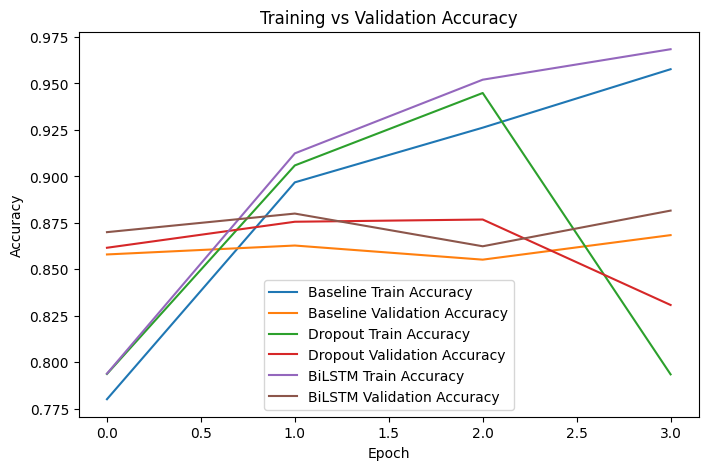

In [37]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Baseline Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Baseline Validation Accuracy"
)

plt.plot(
    history_dropout.history["accuracy"],
    label="Dropout Train Accuracy"
)

plt.plot(
    history_dropout.history["val_accuracy"],
    label="Dropout Validation Accuracy"
)

plt.plot(
    history_bilstm.history["accuracy"],
    label="BiLSTM Train Accuracy"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    label="BiLSTM Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

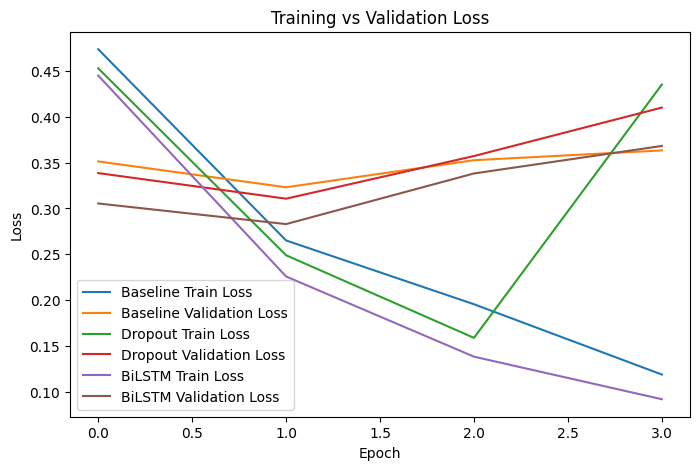

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Baseline Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Baseline Validation Loss"
)

plt.plot(
    history_dropout.history["loss"],
    label="Dropout Train Loss"
)

plt.plot(
    history_dropout.history["val_loss"],
    label="Dropout Validation Loss"
)

plt.plot(
    history_bilstm.history["loss"],
    label="BiLSTM Train Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="BiLSTM Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [39]:
import tensorflow as tf

model_bilstm_128 = tf.keras.Sequential([
    
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_bilstm_128.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_bilstm_128.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm_128 = model_bilstm_128.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 198s 552ms/step - accuracy: 0.7640 - loss: 0.4894 - val_accuracy: 0.8500 - val_loss: 0.3492
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 198s 562ms/step - accuracy: 0.8997 - loss: 0.2626 - val_accuracy: 0.8772 - val_loss: 0.3453
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 195s 554ms/step - accuracy: 0.9356 - loss: 0.1764 - val_accuracy: 0.8704 - val_loss: 0.3236
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 189s 536ms/step - accuracy: 0.9605 - loss: 0.1133 - val_accuracy: 0.8804 - val_loss: 0.4007
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 182s 517ms/step - accuracy: 0.9446 - loss: 0.1521 - val_accuracy: 0.8716 - val_loss: 0.3594


In [41]:
import tensorflow as tf

model_bilstm_reg = tf.keras.Sequential([
    
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            64,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_bilstm_reg.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_bilstm_reg.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm_reg = model_bilstm_reg.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 271s 751ms/step - accuracy: 0.7309 - loss: 0.5343 - val_accuracy: 0.6812 - val_loss: 0.5695
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 263s 747ms/step - accuracy: 0.8337 - loss: 0.3861 - val_accuracy: 0.8476 - val_loss: 0.3538
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 263s 747ms/step - accuracy: 0.8788 - loss: 0.3055 - val_accuracy: 0.8412 - val_loss: 0.3891
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 261s 743ms/step - accuracy: 0.9167 - loss: 0.2209 - val_accuracy: 0.8480 - val_loss: 0.3508
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 263s 747ms/step - accuracy: 0.9405 - loss: 0.1644 - val_accuracy: 0.8692 - val_loss: 0.3499
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 262s 745ms/step - accuracy: 0.9498 - loss: 0.1401 - val_accuracy: 0.8676 - val_loss: 0.3882
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 263s 746ms/step - accuracy: 0.9645 - loss: 0.1033 - val_accuracy: 0.8616 - val_loss: 0.3988


In [44]:
train_lengths = np.array([len(seq) for seq in X_train_seq])
val_lengths = np.array([len(seq) for seq in X_val_seq])
test_lengths = np.array([len(seq) for seq in X_test_seq])

print("Training sequences longer than 500:",
      np.sum(train_lengths > MAX_LEN))

print("Validation sequences longer than 500:",
      np.sum(val_lengths > MAX_LEN))

print("Test sequences longer than 500:",
      np.sum(test_lengths > MAX_LEN))

print("\nPercentage truncated:")

print(
    "Train:",
    np.mean(train_lengths > MAX_LEN) * 100,
    "%"
)

print(
    "Validation:",
    np.mean(val_lengths > MAX_LEN) * 100,
    "%"
)

print(
    "Test:",
    np.mean(test_lengths > MAX_LEN) * 100,
    "%"
)

Training sequences longer than 500: 1766
Validation sequences longer than 500: 215
Test sequences longer than 500: 1850

Percentage truncated:
Train: 7.848888888888888 %
Validation: 8.6 %
Test: 7.436588013024078 %


In [45]:
from sklearn.model_selection import train_test_split

# Recreate train/test from the cleaned dataframe
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

# Remove cross-split duplicates again
cross_split_duplicates = set(train_df["review"]).intersection(
    set(test_df["review"])
)

test_df = test_df[
    ~test_df["review"].isin(cross_split_duplicates)
].copy()

# Training data
X = train_df["cleaned_review"]
y = train_df["sentiment"]

# 90/10 stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

# Test data
X_test = test_df["cleaned_review"]
y_test = test_df["sentiment"]

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 22500
Validation: 2500
Test: 24877


In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 20000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary learned:", len(tokenizer.word_index))

Vocabulary learned: 81858


In [47]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [48]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 500

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

Train shape: (22500, 500)
Validation shape: (2500, 500)
Test shape: (24877, 500)


In [49]:
import tensorflow as tf

VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
LSTM_UNITS = 64

final_model = tf.keras.Sequential([
    
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(LSTM_UNITS)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

final_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [50]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_final = final_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 118s 324ms/step - accuracy: 0.7828 - loss: 0.4483 - val_accuracy: 0.8640 - val_loss: 0.3328
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 112s 317ms/step - accuracy: 0.9102 - loss: 0.2344 - val_accuracy: 0.8780 - val_loss: 0.3108
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 107s 305ms/step - accuracy: 0.9501 - loss: 0.1388 - val_accuracy: 0.8660 - val_loss: 0.3369
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 105s 297ms/step - accuracy: 0.9711 - loss: 0.0834 - val_accuracy: 0.8456 - val_loss: 0.4432


In [51]:
test_loss, test_accuracy = final_model.evaluate(
    X_test_pad,
    y_test,
    batch_size=64
)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

389/389 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.8636 - loss: 0.3456
Final Test Loss: 0.34562599658966064
Final Test Accuracy: 0.8636089563369751


In [52]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob = final_model.predict(
    X_test_pad,
    batch_size=64
)

y_pred = (y_prob >= 0.5).astype(int).flatten()

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

389/389 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86     12405
    Positive       0.85      0.89      0.87     12472

    accuracy                           0.86     24877
   macro avg       0.86      0.86      0.86     24877
weighted avg       0.86      0.86      0.86     24877


Confusion Matrix:
[[10433  1972]
 [ 1421 11051]]
